In [1]:
%%capture
import os, re
if "COLAB_" not in "".join(os.environ.keys()):
    !pip install unsloth
else:
    # Do this only in Colab notebooks! Otherwise use pip install unsloth
    import torch; v = re.match(r"[0-9]{1,}\.[0-9]{1,}", str(torch.__version__)).group(0)
    xformers = "xformers==" + ("0.0.33.post1" if v=="2.9" else "0.0.32.post2" if v=="2.8" else "0.0.29.post3")
    !pip install --no-deps bitsandbytes accelerate {xformers} peft trl triton cut_cross_entropy unsloth_zoo
    !pip install sentencepiece protobuf "datasets==4.3.0" "huggingface_hub>=0.34.0" hf_transfer
    !pip install --no-deps unsloth
!pip install transformers==4.56.2
!pip install --no-deps trl==0.22.2

In [ ]:
#connect to W&B
!pip install unsloth transformers trl wandb 

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: vishwanathasardeshpande (vishwanathasardeshpande-srh-berlin) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


In [5]:
pip install --upgrade transformers unsloth-zoo

  Using cached transformers-4.57.3-py3-none-any.whl.metadata (43 kB)
Using cached transformers-4.57.3-py3-none-any.whl (12.0 MB)
  Attempting uninstall: transformers
    Found existing installation: transformers 4.57.6
    Uninstalling transformers-4.57.6:
      Successfully uninstalled transformers-4.57.6
Note: you may need to restart the kernel to use updated packages.


### Unsloth

In [1]:
from unsloth import FastVisionModel # FastLanguageModel for LLMs
import torch

# 4bit pre quantized models we support for 4x faster downloading + no OOMs.
fourbit_models = [
    "unsloth/Llama-3.2-11B-Vision-Instruct-bnb-4bit", # Llama 3.2 vision support
    "unsloth/Llama-3.2-11B-Vision-bnb-4bit",
    "unsloth/Llama-3.2-90B-Vision-Instruct-bnb-4bit", # Can fit in a 80GB card!
    "unsloth/Llama-3.2-90B-Vision-bnb-4bit",

    "unsloth/Pixtral-12B-2409-bnb-4bit",              # Pixtral fits in 16GB!
    "unsloth/Pixtral-12B-Base-2409-bnb-4bit",         # Pixtral base model

    "unsloth/Qwen2-VL-2B-Instruct-bnb-4bit",          # Qwen2 VL support
    "unsloth/Qwen2-VL-7B-Instruct-bnb-4bit",
    "unsloth/Qwen2-VL-72B-Instruct-bnb-4bit",

    "unsloth/llava-v1.6-mistral-7b-hf-bnb-4bit",      # Any Llava variant works!
    "unsloth/llava-1.5-7b-hf-bnb-4bit",
] # More models at https://huggingface.co/unsloth

model, tokenizer = FastVisionModel.from_pretrained(
    "unsloth/Qwen3-VL-2B-Instruct-unsloth-bnb-4bit",
    load_in_4bit = True, # Use 4bit to reduce memory use. False for 16bit LoRA.
    use_gradient_checkpointing = "unsloth", # True or "unsloth" for long context
)

🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.1.3: Fast Qwen3_Vl patching. Transformers: 4.57.3.
   \\   /|    NVIDIA A40. Num GPUs = 1. Max memory: 44.339 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.9.1+cu128. CUDA: 8.6. CUDA Toolkit: 12.8. Triton: 3.5.1
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.33.post2. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/2.41G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/213 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/782 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/817 [00:00<?, ?B/s]

We now add LoRA adapters for parameter efficient finetuning - this allows us to only efficiently train 1% of all parameters.

**[NEW]** We also support finetuning ONLY the vision part of the model, or ONLY the language part. Or you can select both! You can also select to finetune the attention or the MLP layers!

In [3]:
model = FastVisionModel.get_peft_model(
    model,
    finetune_vision_layers     = True, # False if not finetuning vision layers
    finetune_language_layers   = True, # False if not finetuning language layers
    finetune_attention_modules = True, # False if not finetuning attention layers
    finetune_mlp_modules       = True, # False if not finetuning MLP layers

    r = 16,           # The larger, the higher the accuracy, but might overfit
    lora_alpha = 16,  # Recommended alpha == r at least
    lora_dropout = 0,
    bias = "none",
    random_state = 3407,
    use_rslora = False,  # We support rank stabilized LoRA
    loftq_config = None, # And LoftQ
    # target_modules = "all-linear", # Optional now! Can specify a list if needed
)

RuntimeError: Unsloth: You already added LoRA adapters to your model!

<a name="Data"></a>
### Data Prep
We'll be using a sampled dataset of handwritten maths formulas. The goal is to convert these images into a computer readable form - ie in LaTeX form, so we can render it. This can be very useful for complex formulas.

You can access the dataset [here](https://huggingface.co/datasets/unsloth/LaTeX_OCR). The full dataset is [here](https://huggingface.co/datasets/linxy/LaTeX_OCR).

In [ ]:
from datasets import load_dataset
dataset = load_dataset("VishwanathAS/Carla_dataset_town10", split = "train")

README.md:   0%|          | 0.00/402 [00:00<?, ?B/s]

train-00000-of-00002.parquet:   0%|          | 0.00/475M [00:00<?, ?B/s]

train-00001-of-00002.parquet:   0%|          | 0.00/475M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/10500 [00:00<?, ? examples/s]

Let's take an overview look at the dataset. We shall see what the 3rd image is, and what caption it had.

In [5]:
dataset

Dataset({
    features: ['image', 'trajectory', 'instruction', 'sample_id'],
    num_rows: 10500
})

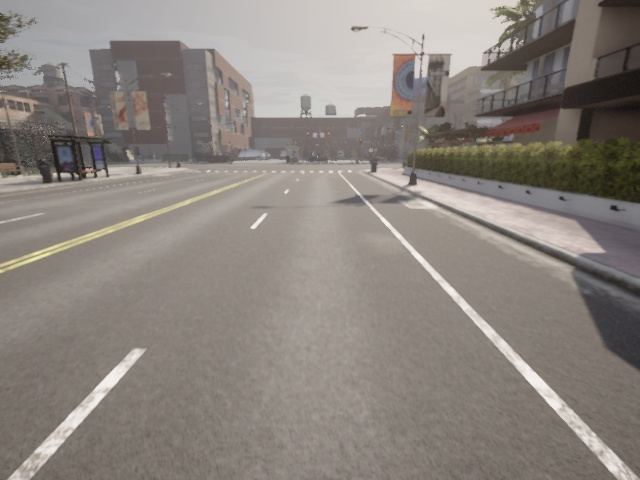

In [6]:
dataset[2]["image"]

In [7]:
dataset[2]["trajectory"]

'[[322, 420, 9], [321, 390, 12], [321, 375, 15], [321, 365, 18], [321, 359, 21], [321, 354, 24], [321, 350, 27], [321, 348, 30]]'

In [ ]:
def split_dataset(dataset, train_routes, val_routes, test_routes):
    """Split by route names"""
    train = dataset.filter(lambda x: x['route_name'] in train_routes)
    val = dataset.filter(lambda x: x['route_name'] in val_routes)
    test = dataset.filter(lambda x: x['route_name'] in test_routes)
    
    print(f"✅ Train: {len(train)} samples")
    print(f"✅ Val:   {len(val)} samples")
    print(f"✅ Test:  {len(test)} samples")
    
    return train, val, test

# Define routes
train_routes = [f'{t}_{i}' for t in ['left','right','straight','loop','mix'] for i in range(1,6)]
val_routes = [f'{t}_{i}' for t in ['left','right','straight','loop','mix'] for i in range(6,8)]
test_routes = [f'{t}_8' for t in ['left','right','straight','loop','mix']]


train, val, test = split_dataset(dataset, train_routes, val_routes, test_routes)


To format the dataset, all vision finetuning tasks should be formatted as follows:

```python
[
{ "role": "user",
  "content": [{"type": "text",  "text": Q}, {"type": "image", "image": image} ]
},
{ "role": "assistant",
  "content": [{"type": "text",  "text": A} ]
},
]
```

In [ ]:


def convert_to_conversation(sample):
    user_text = f"""Current Status:
  - Speed: {sample['speed_kmh']:.1f} km/h
  - Navigation: {sample['nav_command']}

  Predict the driving trajectory as pixel coordinates.
  Output format: [[x1,y1], [x2,y2], [x3,y3], [x4,y4], [x5,y5]]"""

      # Build assistant response (just trajectory)
    trajectory_str = str(sample['trajectory_pixels'])
    assistant_text = trajectory_str
      
      # Build conversation
    conversation = {
          "messages": [
              {
                  "role": "user",
                  "content": [
                      {
                          "type": "image",
                          "image": sample['image_path']
                      },
                      {
                          "type": "text",
                          "text": user_text
                      }
                  ]
              },
              {
                  "role": "assistant",
                  "content": [
                      {
                          "type": "text",
                          "text": assistant_text
                      }
                  ]
              }
          ],
          "route_name": sample['route_name'],  # Keep for filtering
          "episode_id": sample['episode_id'],
          "frame_idx": sample['frame_idx']
      }
    return conversation

Let's convert the dataset into the "correct" format for finetuning:

In [ ]:
# converted_dataset = [convert_to_conversation(sample) for sample in dataset]
train_conversations = [convert_to_conversation(sample) for sample in train]
val_conversations = [convert_to_conversation(sample) for sample in val]
test_conversations = [convert_to_conversation(sample) for sample in test]

We look at how the conversations are structured for the first example:

In [ ]:
# converted_dataset[0]
train_conversations[0]

{'messages': [{'role': 'user',
   'content': [{'type': 'text',
     'text': 'Given this front camera view, output the planned driving trajectory as pixel coordinates with distances: [[x, y, d], ...]'},
    {'type': 'image',
     'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=640x480>}]},
  {'role': 'assistant',
   'content': [{'type': 'text',
     'text': '[[281, 478, 6], [279, 411, 9], [274, 385, 12], [268, 371, 15], [261, 362, 18], [255, 357, 21], [247, 352, 24], [237, 349, 27], [227, 347, 30]]'}]}]}

In [26]:
import random

def split_list(data_list, eval_ratio=0.1, ):
    data_list = data_list.copy()   # avoid mutating original list
    random.shuffle(data_list)

    split_idx = int((1 - eval_ratio) * len(data_list))

    train_list = data_list[:split_idx]
    eval_list  = data_list[split_idx:]

    return train_list, eval_list


In [27]:
converted_train_dataset, converted_eval_dataset = split_list(
    converted_dataset,
    eval_ratio=0.1,
)

Let's first see before we do any finetuning what the model outputs for the first example!

In [ ]:
FastVisionModel.for_inference(model) # Enable for inference!


base = train_conversations[0]

image = base["messages"][0]["content"][0]["image"]
instruction = base["messages"][0]["content"][1]["text"]

messages = [
    {"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

```json
[
	{"trajectory": [[558, 59, 1217, 59], "description": "The waypoint indicates a forward progression along a road. The coordinates suggest a direct, straight-line travel path down the road. The image shows a view of a modern city street with buildings on both sides and a bus stop on the left. The road is relatively clear of obstacles and appears to have no immediate obstructions in the direction of travel. This is likely an early phase of navigation on a typical city street with a direct forward path, possibly with the vehicle moving in a straight trajectory toward


<a name="Train"></a>
### Train the model
Now let's train our model. We do 60 steps to speed things up, but you can set `num_train_epochs=1` for a full run, and turn off `max_steps=None`. We also support TRL's `DPOTrainer`!

We use our new `UnslothVisionDataCollator` which will help in our vision finetuning setup.

In [ ]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig


FastVisionModel.for_training(model) # Enable for training!

trainer = SFTTrainer(
    model = model,
    tokenizer = tokenizer,
    data_collator = UnslothVisionDataCollator(model, tokenizer), # Must use!
    train_dataset = converted_dataset,
    args = SFTConfig(
        per_device_train_batch_size = 2,
        gradient_accumulation_steps = 4,
        warmup_steps = 5,
        max_steps = 30,
        # num_train_epochs = 1, # Set this instead of max_steps for full training runs
        learning_rate = 2e-4,
        logging_steps = 1,
        optim = "adamw_8bit",
        weight_decay = 0.001,
        lr_scheduler_type = "linear",
        seed = 3407,
        output_dir = "outputs",
        report_to = "wandb",     # For Weights and Biases

        # You MUST put the below items for vision finetuning:
        remove_unused_columns = False,
        dataset_text_field = "",
        dataset_kwargs = {"skip_prepare_dataset": True},
        max_length = 2048,
    ),
)

Unsloth: Model does not have a default image size - using 512


In [35]:
# @title Show current memory stats
gpu_stats = torch.cuda.get_device_properties(0)
start_gpu_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
max_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)
print(f"GPU = {gpu_stats.name}. Max memory = {max_memory} GB.")
print(f"{start_gpu_memory} GB of memory reserved.")

GPU = NVIDIA A40. Max memory = 44.339 GB.
2.482 GB of memory reserved.


In [ ]:
from unsloth.trainer import UnslothVisionDataCollator
from trl import SFTTrainer, SFTConfig
from unsloth import FastVisionModel

import wandb

wandb.init(
    project="VLA Driver",
    # name="qwen2.5-vl-sft-v1",
    name = "qwen3-vl-sft-v1",
    config={
        "model": "Qwen3-VL",
        "task": "trajectory_prediction",
        "precision": "fp16",
    }
)

FastVisionModel.for_training(model)  # Enable for training!

trainer = SFTTrainer(
    model=model,
    tokenizer=tokenizer,

    data_collator=UnslothVisionDataCollator(
        model,
        tokenizer,
    ),  # Must use!

    train_dataset=train_conversations,
    eval_dataset=test_conversations,   # 👈 ADD EVAL DATASET

    args=SFTConfig(
        # -----------------------------
        # Training
        # -----------------------------
        per_device_train_batch_size=3,
        per_device_eval_batch_size=2,      # 👈 ADD
        gradient_accumulation_steps=3,

        learning_rate=2e-4,
        warmup_steps=5,
        # max_steps=90,
        num_train_epochs=3,

        optim="adamw_8bit",
        weight_decay=0.001,
        lr_scheduler_type="linear",

        # -----------------------------
        # Logging & Evaluation
        # -----------------------------
        logging_steps=1,
        eval_strategy="steps",       # 👈 ENABLE EVAL
        eval_steps=50,                      # 👈 RUN EVAL EVERY N STEPS

        save_strategy="steps",
        save_steps=50,
        save_total_limit=2,

        report_to="wandb",                 # For Weights & Biases
        run_name="qwen3-vl-sft",

        # -----------------------------
        # Vision finetuning (MANDATORY)
        # -----------------------------
        remove_unused_columns=False,
        dataset_text_field="messages",
        dataset_kwargs={"skip_prepare_dataset": True},
        max_length=2048,

        # -----------------------------
        # Misc
        # -----------------------------
        output_dir="outputs",
        seed=28
    ),
)
trainer_stats = trainer.train()


Unsloth: Model does not have a default image size - using 512


The model is already on multiple devices. Skipping the move to device specified in `args`.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 9,450 | Num Epochs = 1 | Total steps = 30
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 4 x 1) = 8
 "-____-"     Trainable parameters = 23,724,032 of 2,151,256,064 (1.10% trained)
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.
wandb: Currently logged in as: vishwanathasardeshpande (vishwanathasardeshpande-srh-berlin) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


wandb: Detected [huggingface_hub.inference] in use.
wandb: Use W&B Weave for improved LLM call tracing. Install Weave with `pip install weave` then add `import weave` to the top of your script.
wandb: For more information, check out the docs at: https://weave-docs.wandb.ai/


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss,Validation Loss
5,1.378700,1.185214
10,0.921500,0.832765
15,0.588500,0.588466
20,0.421800,0.445100
25,0.360700,0.366360
30,0.360700,0.335695


Unsloth: Not an error, but Qwen3VLForConditionalGeneration does not accept `num_items_in_batch`.
Using gradient accumulation will be very slightly less accurate.
Read more on gradient accumulation issues here: https://unsloth.ai/blog/gradient


eval/loss,█▅▃▂▁▁
eval/runtime,▃▇█▅▁▇
eval/samples_per_second,▅▂▁▄█▂
eval/steps_per_second,▅▂▁▃█▂
train/epoch,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
train/global_step,▁▁▁▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▅▅▅▅▆▆▆▆▆▇▇▇▇▇█████
train/grad_norm,▇█▇▆▅▄▃▃▄▅▆▄▂▁▂▁▁▂▁▁▂▁▁▂▁▁▂▂▁▁
train/learning_rate,▁▂▄▅▇██▇▇▇▇▆▆▆▅▅▅▅▄▄▄▄▃▃▃▂▂▂▂▁
train/loss,███▇▇▆▅▄▄▄▄▃▃▃▂▃▂▂▂▂▂▁▁▁▁▁▁▁▁▁
eval/loss,0.3357
eval/runtime,171.434


In [37]:
# @title Show final memory and time stats
used_memory = round(torch.cuda.max_memory_reserved() / 1024 / 1024 / 1024, 3)
used_memory_for_lora = round(used_memory - start_gpu_memory, 3)
used_percentage = round(used_memory / max_memory * 100, 3)
lora_percentage = round(used_memory_for_lora / max_memory * 100, 3)
print(f"{trainer_stats.metrics['train_runtime']} seconds used for training.")
print(
    f"{round(trainer_stats.metrics['train_runtime']/60, 2)} minutes used for training."
)
print(f"Peak reserved memory = {used_memory} GB.")
print(f"Peak reserved memory for training = {used_memory_for_lora} GB.")
print(f"Peak reserved memory % of max memory = {used_percentage} %.")
print(f"Peak reserved memory for training % of max memory = {lora_percentage} %.")

1131.287 seconds used for training.
18.85 minutes used for training.
Peak reserved memory = 3.203 GB.
Peak reserved memory for training = 0.721 GB.
Peak reserved memory % of max memory = 7.224 %.
Peak reserved memory for training % of max memory = 1.626 %.


<a name="Inference"></a>
### Inference
Let's run the model! You can change the instruction and input - leave the output blank!

We use `min_p = 0.1` and `temperature = 1.5`. Read this [Tweet](https://x.com/menhguin/status/1826132708508213629) for more information on why.

In [ ]:
FastVisionModel.for_inference(model) # Enable for inference!


test_sample = val_conversations[0]
image = test_sample["messages"][0]["content"][0]["image"]
instruction = test_sample["messages"][0]["content"][1]["text"]


messages = [
    {"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

[[329, 450, 9], [329, 396, 12], [334, 380, 15], [344, 372, 18], [356, 368, 21], [372, 364, 24], [394, 360, 27], [420, 359, 30], [450, 357, 33], [48


<a name="Save"></a>
### Saving, loading finetuned models
To save the final model as LoRA adapters, either use Huggingface's `push_to_hub` for an online save or `save_pretrained` for a local save.

**[NOTE]** This ONLY saves the LoRA adapters, and not the full model. To save to 16bit or GGUF, scroll down!

In [39]:
model.save_pretrained("lora_model")  # Local saving
tokenizer.save_pretrained("lora_model")
# model.push_to_hub("your_name/lora_model", token = "...") # Online saving
# tokenizer.push_to_hub("your_name/lora_model", token = "...") # Online saving

[]

Now if you want to load the LoRA adapters we just saved for inference, set `False` to `True`:

In [ ]:
from unsloth import FastVisionModel
model, tokenizer = FastVisionModel.from_pretrained(
        model_name = "lora_model", # YOUR MODEL YOU USED FOR TRAINING
        load_in_4bit = True, # Set to False for 16bit LoRA
    )
FastVisionModel.for_inference(model) # Enable for inference!
image = test_sample["messages"][0]["content"][0]["image"]
instruction = test_sample["messages"][0]["content"][1]["text"]

messages = [
    {"role": "user", "content": [
        {"type": "image", "image": image},
        {"type": "text", "text": instruction}
    ]}
]
input_text = tokenizer.apply_chat_template(messages, add_generation_prompt = True)
inputs = tokenizer(
    image,
    input_text,
    add_special_tokens = False,
    return_tensors = "pt",
).to("cuda")

from transformers import TextStreamer
text_streamer = TextStreamer(tokenizer, skip_prompt = True)
_ = model.generate(**inputs, streamer = text_streamer, max_new_tokens = 128,
                   use_cache = True, temperature = 1.5, min_p = 0.1)

[[330, 403, 9], [332, 398, 12], [334, 395, 15], [337, 394, 18], [341, 393, 21], [347, 392, 24], [353, 391, 27], [359, 390, 30], [367, 390, 33], [37


### Saving to float16 for VLLM

We also support saving to `float16` directly. Select `merged_16bit` for float16. Use `push_to_hub_merged` to upload to your Hugging Face account! You can go to https://huggingface.co/settings/tokens for your personal tokens.

In [42]:
model.push_to_hub_merged("VishwanathAS/Qwen3-VLA-Driver", tokenizer)

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Found HuggingFace hub cache directory: /workspace/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

...

Unsloth: Merging weights into 16bit:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Unsloth: Merging weights into 16bit: 100%|██████████| 1/1 [01:02<00:00, 62.28s/it]


Unsloth: Merge process complete. Saved to `/workspace/VishwanathAS/Qwen3-VLA-Driver`


Save a Quantised GGUF

In [44]:
model.push_to_hub_gguf("VishwanathAS/Qwen3-VL-Driver-GGUF", tokenizer, quantization_method = "q4_k_m")

Unsloth: Converting model to GGUF format...
Unsloth: Merging model weights to 16-bit format...
Found HuggingFace hub cache directory: /workspace/.cache/huggingface/hub
Checking cache directory for required files...
Cache check failed: model.safetensors not found in local cache.
Not all required files found in cache. Will proceed with downloading.
Checking cache directory for required files...
Cache check failed: tokenizer.model not found in local cache.
Not all required files found in cache. Will proceed with downloading.


Unsloth: Preparing safetensor model files:   0%|          | 0/1 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/4.26G [00:00<?, ?B/s]

Unsloth: Preparing safetensor model files: 100%|██████████| 1/1 [00:03<00:00,  3.49s/it]


Note: tokenizer.model not found (this is OK for non-SentencePiece models)


...

Uploading qwen3-vl-2b-instruct.BF16-mmproj.gguf...


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

Uploading config.json...
Unsloth: Successfully uploaded GGUF to https://huggingface.co/VishwanathAS/Qwen3-VL-Driver-GGUF
Unsloth: Cleaning up temporary files...


'VishwanathAS/Qwen3-VL-Driver-GGUF'